# Plotting for Project 1

In [156]:
%load_ext autoreload
%autoreload 2
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run local descent

In [157]:
np.random.seed(0)
# 3 random initial points for each function with integer values between -5 and 5
x0_map = {
    "Simple1": np.array([[-2,2], [3, 4], [0, 0]]),
    "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
    "Simple3": np.array([[1,1,1,1], [-1, -3, -1, -1], [4, 2, 1, 0]]),
}
x_best_map = {
    "Simple1": np.array([1, 1]),
    "Simple2": np.array([[3, 2], [-2.805, 3.131],[-3.779, -3.283], [3.584, -1.848]]),
    "Simple3": np.array([0,0,0,0]),
}

In [158]:
from project1_py.helpers import Simple1, Simple2, Simple3
from project1_py.project1 import local_descent

hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        history = local_descent(p.f, p.g, x0, p.n, p.count)
        hists[(p_name.__name__, tuple(x0))] = history
        print(f"Best solution for {p_name.__name__} starting at {x0}: {history[-1]} with value {p.f(history[-1])}")

Best solution for Simple1 starting at [-2  2]: [-1.41919896  2.04093121] with value 5.924377230379582
Best solution for Simple1 starting at [3 4]: [2.01358832 4.16429242] with value 2.2319661681049574
Best solution for Simple1 starting at [0 0]: [0.22779889 0.05842397] with value 0.6005607858266508
Best solution for Simple2 starting at [2 2]: [3.00771832 1.99858544] with value 0.002025196190577682
Best solution for Simple2 starting at [-1 -1]: [-3.76311097 -3.29386417] with value 0.025121949925799768
Best solution for Simple2 starting at [3 3]: [3.00248924 2.0357262 ] with value 0.02407944175332241
Best solution for Simple3 starting at [1 1 1 1]: [ 0.74191252 -0.13096466  0.28685356  0.46477589] with value 0.7861675550877347
Best solution for Simple3 starting at [-1 -3 -1 -1]: [-0.66392768  0.03014512 -0.29645901 -0.47055958] with value 0.4476304670756758
Best solution for Simple3 starting at [4 2 1 0]: [ 1.42437037 -0.00368192  0.3741767   0.98427927] with value 4.481398867398936


## Plot contours and path for Rosenbrock function

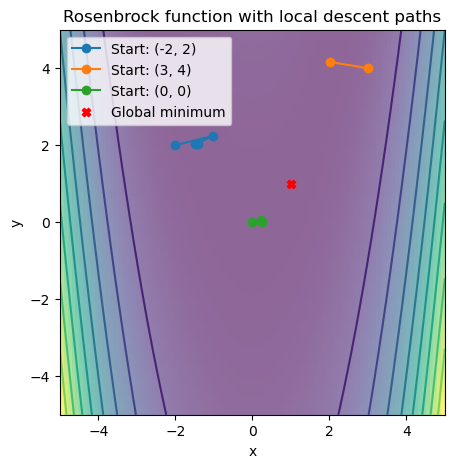

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
x, y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
# heatmap
plt.imshow(Simple1().f(np.array([x, y])), extent=(-5, 5, -5, 5), origin="lower", cmap="viridis", alpha=0.6)
plt.contour(x, y, Simple1().f(np.array([x, y])), levels=10, cmap="viridis")
for key, history in hists.items():
    if key[0] == "Simple1":
        plt.plot(np.array(history)[:, 0], np.array(history)[:, 1], marker="o", label=f"Start: {key[1]}")
plt.scatter(x_best_map["Simple1"][0], x_best_map["Simple1"][1], marker="X", color="red", label="Global minimum")
plt.title("Rosenbrock function with local descent paths")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("figs/rosenbrock_local_descent.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Convergence plots

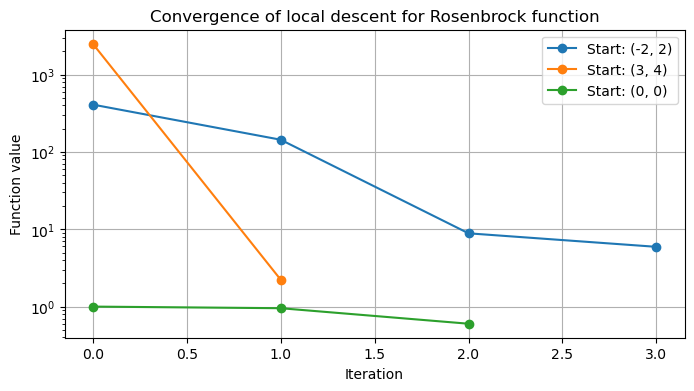

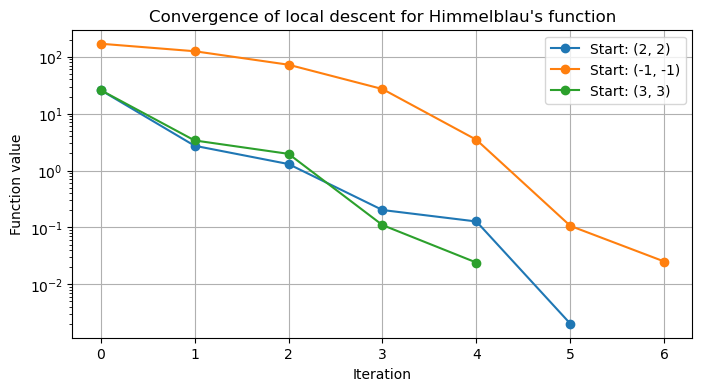

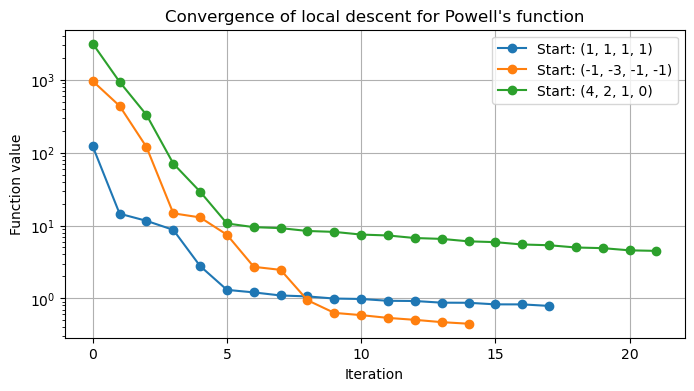

In [160]:
# convergence plot for every run
# for every problem
title_map = {
    "Simple1": "Rosenbrock function",
    "Simple2": "Himmelblau's function",
    "Simple3": "Powell's function",
}
for p_name in [Simple1, Simple2, Simple3]:
    plt.figure(figsize=(8, 4))
    for key, history in hists.items():
        if key[0] == p_name.__name__:
            p = p_name()
            hist_single = [p.f(x) for x in history]
            plt.plot(hist_single, marker="o", label=f"Start: {key[1]}")

    plt.title(f"Convergence of local descent for {title_map.get(p_name.__name__, p_name.__name__)}")
    plt.xlabel("Iteration")
    plt.ylabel("Function value")
    plt.yscale("log")
    plt.legend()
    plt.grid()
    plt.savefig(f"figs/{p_name.__name__}_local_descent_convergence.pdf", dpi=300, bbox_inches="tight")
    plt.show()